In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
df = pd.read_csv("../data/atp_matches_2000_2019_clean.csv")

features = [
    "elo_diff",
    "selo_diff",
    "serv_diff",
    "comp_diff",
    "form_diff",
]

X = df[features]

# Standardointi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA (ota vaikka kaikki komponentit)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Varianssi
explained = pd.Series(pca.explained_variance_ratio_, name="Explained variance")
print(explained)

# Komponentit
components = pd.DataFrame(
    pca.components_,
    columns=features,
    index=[f"PC{i+1}" for i in range(len(features))]
)

print(components)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

0    0.712810
1    0.169413
2    0.078284
3    0.023330
4    0.016163
Name: Explained variance, dtype: float64
     elo_diff  selo_diff  serv_diff  comp_diff  form_diff
PC1  0.486075   0.451710   0.430932   0.376493   0.481912
PC2 -0.295778  -0.386289  -0.304344   0.737228   0.356602
PC3 -0.252058  -0.525002   0.799663  -0.098407   0.108146
PC4  0.513144  -0.487294  -0.276834  -0.408386   0.505777
PC5 -0.591097   0.365590  -0.074664  -0.371865   0.610810


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    log_loss,
    brier_score_loss,
)

import seaborn as sns

# Load dataset
df = pd.read_csv("../data/atp_matches_2000_2019_clean.csv")

# Feature groups
pca_features = [
    "elo_diff",
    "selo_diff",
    "comp_diff",
    "serv_diff",
    "form_diff",
]

other_features = [
    "rank_diff",
    "rank_points_diff",
    "age_diff",
]

X = pca_features + other_features
y = "result"

# Storage
dates = []
predictions = []
actuals = []
probabilities = []
best_params_list = []
cv_monitor = []
coef_list = []

# Rolling setup
WINDOW_SIZE = 10000
STEP = 100

LOGIT = LogisticRegression(
    max_iter=5000,
    random_state=1
)

# Preprocessing: PCA only for performance features
preprocessor = ColumnTransformer([
    ("pca_block", Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=2))
    ]), pca_features),

    ("other_block", StandardScaler(), other_features)
])

# Pipeline
pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LOGIT),
])

# Hyperparameter grid
param_grid = {
    "clf__C": [0.01, 0.1, 1, 10]
}

# Rolling window loop
for i in range(WINDOW_SIZE, len(df), STEP):

    train_data = df.iloc[i-WINDOW_SIZE:i]
    test_data = df.iloc[i:i+STEP]

    if len(test_data) == 0:
        break

    X_train = train_data[X]
    y_train = train_data[y]
    X_test = test_data[X]
    y_test = test_data[y]

    tscv = TimeSeriesSplit(n_splits=2)

    search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=tscv,
        n_jobs=-1,
        scoring="neg_log_loss",
        refit=True,
        return_train_score=True
    )

    search.fit(X_train, y_train)
    
    # --- STORE COEFFICIENTS ---
    best_model = search.best_estimator_
    coefs = best_model.named_steps["clf"].coef_[0]
    coef_list.append(coefs)
    
    # CV monitoring
    res = pd.DataFrame(search.cv_results_)
    best_row = res.iloc[search.best_index_]

    cv_monitor.append({
        "Index": i,
        "Date": test_data["tourney_date"].iloc[0],
        "Best_Params": search.best_params_,
        "Mean_Train_Score": float(best_row["mean_train_score"]),
        "Mean_Valid_Score": float(best_row["mean_test_score"]),
    })

    # Predictions
    best_params_list.append(search.best_params_)
    dates.extend(test_data["tourney_date"].tolist())

    preds = search.predict(X_test)
    probs = search.predict_proba(X_test)[:, 1]

    predictions.extend(preds)
    probabilities.extend(probs)
    actuals.extend(y_test.tolist())

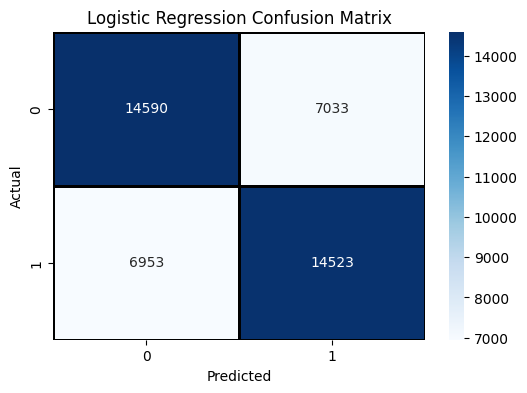

Balanced Accuracy: 0.675
Log Loss: 0.595
Brier Score: 0.205


In [ ]:
#Confusion matrix
cm = confusion_matrix(actuals, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", linewidths=1, linecolor='black')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

#Accuracy
accuracy = balanced_accuracy_score(actuals, predictions)
print(f"Balanced Accuracy: {accuracy:.3f}")

#Log loss
logloss = log_loss(actuals, probabilities)
print(f"Log Loss: {logloss:.3f}")

#Brier score
brier_score = brier_score_loss(actuals, probabilities)
print(f"Brier Score: {brier_score:.3f}")


            Feature  Coefficient  Abs_Coefficient
0               PC1     0.401903         0.401903
2         rank_diff    -0.221319         0.221319
1               PC2    -0.195083         0.195083
3  rank_points_diff     0.186777         0.186777
4          age_diff    -0.116203         0.116203


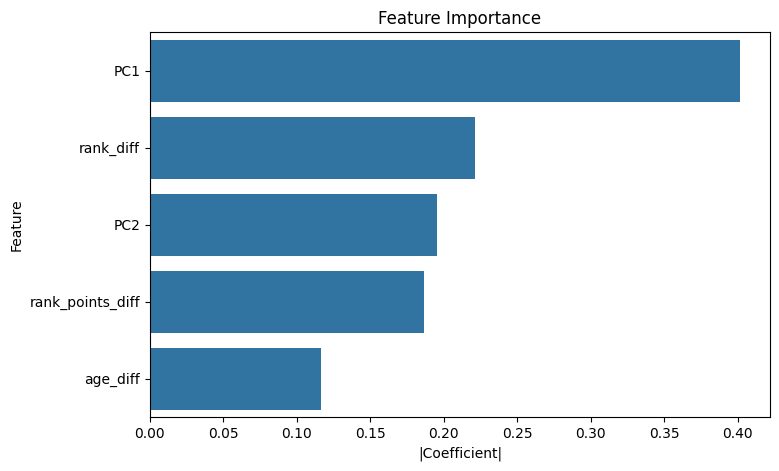

: 

In [ ]:
# ROLLING FEATURE IMPORTANCE

coef_array = np.array(coef_list)
mean_coefs = coef_array.mean(axis=0)

feature_names = ["PC1", "PC2"] + other_features

feature_importance_logit = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": mean_coefs,
    "Abs_Coefficient": np.abs(mean_coefs)
}).sort_values(by="Abs_Coefficient", ascending=False)

print(feature_importance_logit)

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(
    data=feature_importance_logit,
    x="Abs_Coefficient",
    y="Feature"
)
plt.title("Feature Importance")
plt.xlabel("|Coefficient|")
plt.ylabel("Feature")
plt.show()